Taavon Peoples QML Project

Data Encoding

Notes for what's next:
Add State and City into the feature map

Try to train the model with ON2 included then predict the ON2 based on the other features and see how it maps. This should be as close to the real number as possible 
We can use this to show the effectiveness of the model 
possibly compare the expected number with the real one

This try different ways to map it and compare the results (z_parameter_map, zz_parameter_map, manual designs using cnot and other gates)

For manually designed feature mapping, think about what features [data labels (white, black, etc)] are related to each other and possibly the feature that we are trying to predict

For example, add a cnot if features are related so 
-----

Change the data mapping so that grade is the label for training. Grades A & B will be +1 and Grades C & D will be -1 

In [5]:
# If you have not already, install scikit learn
%pip install scikit-learn
%pip install qiskit
%pip install qiskit-aer --quiet
%pip install pylatexenc
%pip install matplotlib
%pip install qiskit-ibm-runtime
%pip install qiskit-ibm-transpiler

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path
import importlib

# add project root (current working dir or nearest parent containing utils.py) to sys.path and import utils
cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
     token="yZoR4zRA8X7ZX2rauN_pkmyBrId1CJbbXR1RoN_dFvJh",
     set_as_default = True
     )

Step 1 Data Encoding
Map inputs to quantum circuit

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import init

# This only needs to be run once, as the dataset is cached after the first run
dataset = init()
# Baltimore statistics
baltimore_dataset = dataset[dataset['City'] == 'Baltimore, MD']

print(dataset["Black"][:20])

0      0
1      1
2      0
3      0
4      0
5     17
6     87
7      1
8      0
9      2
10     5
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     2
19     3
Name: Black, dtype: int64


Need to adjust the data for training
pre-processing needed here

Should adjust the data as follows for the initial test
Set each value as a percentage of the total, use that to predict the NO2 level or PM25 levels

Each Demographic is a feature here (Black, Whtie, Hispanic, etc)

In [29]:
from itertools import count


baltimore_dataset

baltimore_dataset['Grade'].value_counts()

test_set = baltimore_dataset[baltimore_dataset['Total'] > 100 ]
test_set =  test_set[test_set['Black'] > test_set['White']]
#baltimore_dataset['Total'].value_counts().plot(kind='line')

test_set

,CUA,City,GEOID,Grade,PHOLC,Asian,Black,Hispanic,White,Other,Total,NO2,PM25
7928,"Baltimore, MD","Baltimore, MD",245100901003001,A,0.634769,1,256,4,83,7,351,11.7336,10.8389
7930,"Baltimore, MD","Baltimore, MD",245100901003008,A,1.000000,1,102,0,5,0,108,11.9954,10.8910
7931,"Baltimore, MD","Baltimore, MD",245100901003011,A,0.087063,1,79,5,20,4,109,11.5192,10.7318
7932,"Baltimore, MD","Baltimore, MD",245100901003012,A,0.182217,3,99,3,9,0,114,11.6741,10.6286
7942,"Baltimore, MD","Baltimore, MD",245100903002003,A,0.288665,17,333,4,7,2,363,13.5370,10.5949
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005240,"Baltimore, MD","Baltimore, MD",245102805002028,D,1.000000,0,100,0,3,1,104,19.3395,11.3620
1005242,"Baltimore, MD","Baltimore, MD",245102805002030,D,1.000000,0,148,2,0,1,151,20.1886,11.2823
1005248,"Baltimore, MD","Baltimore, MD",245102805003016,D,1.000000,0,158,0,0,2,160,19.2670,11.3628
1005249,"Baltimore, MD","Baltimore, MD",245102805004001,D,1.000000,0,126,0,1,0,127,19.0501,11.3791


In [8]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 2023728 entries, 0 to 2023727
Data columns (total 13 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CUA       str    
 1   City      str    
 2   GEOID     str    
 3   Grade     str    
 4   PHOLC     float64
 5   Asian     int64  
 6   Black     int64  
 7   Hispanic  int64  
 8   White     int64  
 9   Other     int64  
 10  Total     int64  
 11  NO2       float64
 12  PM25      float64
dtypes: float64(3), int64(6), str(4)
memory usage: 200.7 MB
None


In [18]:
def encode_grade(grade):
    if grade == 'A':
        return 1
    elif grade == 'B':
        return 2
    elif grade == 'C':
        return 3
    elif grade == 'D':
        return 4
    elif grade == 'F':
        return 5
    else:
        return 0
    
def convert_to_label(grade):
    if grade in ['A', 'B']:
        return 1
    else:
        return -1

In [20]:
# Format the data for the first 10 rows, to be used as input to the quantum machine learning model
subset = baltimore_dataset.head(100)
array_stacked = np.column_stack([subset[col].values for col in ['Grade', 'White','Black', 'Hispanic', 'Asian', 'Other', 'Total', 'NO2', 'PHOLC', 'PM25']])
processed_data = list()

# Normalize the data by dividing each value by the total number of samples in that row (column 6)
# Normalize the totals by dividing by the max total in the dataset
max = np.max(array_stacked[:, 6])
for row in array_stacked:
    processed_data.append(np.array([
                           row[1] / row[6], # % of White population
                           row[2] / row[6], # % of Black population
                           row[3] / row[6], # % of Hispanic population
                           row[4] / row[6], # % of Asian population
                           row[5] / row[6], # % of Other population
                           row[6] / max,     # Normalized total
                           row[7],           # NO2 levels
                           row[8],           # PHOLC levels
                           row[9],          # PM25 levels
                           convert_to_label(row[0])]))  # Grade is encoded as a number from 1 to 5, with 0 for missing values          
processed_data = np.array(processed_data)


                                         

print(processed_data) 

[[6.15384615e-01 0.00000000e+00 1.53846154e-01 2.30769231e-01
  0.00000000e+00 3.58126722e-02 1.00206000e+01 2.08685054e-01
  1.12915000e+01 1.00000000e+00]
 [8.65168539e-01 6.36704120e-02 5.61797753e-02 1.49812734e-02
  0.00000000e+00 7.35537190e-01 6.64551000e+00 1.00000000e+00
  9.56659000e+00 1.00000000e+00]
 [7.69230769e-01 7.69230769e-02 5.12820513e-02 1.02564103e-01
  0.00000000e+00 1.07438017e-01 6.55228000e+00 1.00000000e+00
  9.54666000e+00 1.00000000e+00]
 [8.18181818e-01 5.05050505e-02 0.00000000e+00 1.21212121e-01
  1.01010101e-02 2.72727273e-01 6.45193000e+00 1.00000000e+00
  9.85791000e+00 1.00000000e+00]
 [6.66666667e-01 7.69230769e-02 1.28205128e-01 1.02564103e-01
  2.56410256e-02 1.07438017e-01 9.29299000e+00 1.00000000e+00
  1.10452000e+01 1.00000000e+00]
 [8.98876404e-01 5.61797753e-02 0.00000000e+00 4.49438202e-02
  0.00000000e+00 2.45179063e-01 8.57727000e+00 1.00000000e+00
  1.14190000e+01 1.00000000e+00]
 [8.57142857e-01 0.00000000e+00 8.16326531e-02 2.04081633e

circuit depth =  9


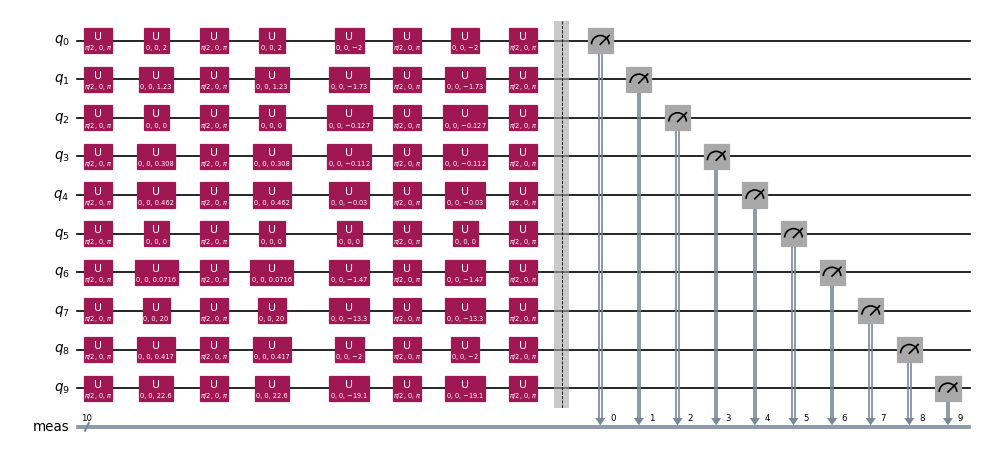

In [11]:
# Sample with two rows


from qiskit.circuit.library import z_feature_map
from qiskit.circuit.library import unitary_overlap

# Data points with labels removed, for inner product
#train_data = [dataset["Black"][:10], dataset["White"][:10]]
train_data=[processed_data[0], processed_data[1]]

# Encode the data into quantum states using the ZFeatureMap
fm = z_feature_map(feature_dimension=np.shape(train_data)[1])

num_qubits = fm.num_qubits

#Assign Params
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

Create Ansatz to show data relationships. 

Think about how the values are related

5
2+ qubit depth: 3


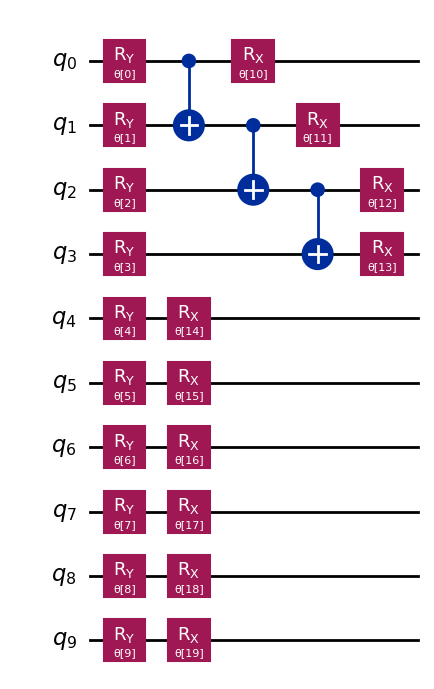

In [12]:
# Import the necessary packages
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(num_qubits)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * num_qubits)

# A first variational layer:
for i in range(num_qubits):
    qnn_circuit.ry(params[i], i)

# Here is a list of qubit pairs between which we want CNOT gates. The choice of these is not yet obvious.
qnn_cnot_list = [[0, 1], [1, 2], [2, 3]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(num_qubits):
    qnn_circuit.rx(params[num_qubits + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Draw the circuit
qnn_circuit.draw("mpl")

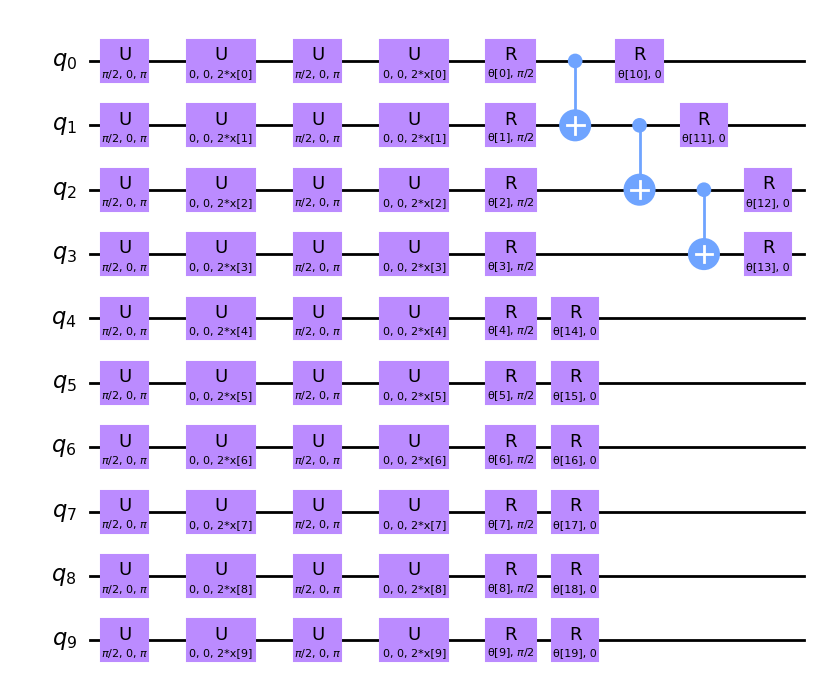

In [13]:
# QNN ansatz
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(fm, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

In [14]:
# Training with more data

# what are we doing for the labels? 

train_size = 75
#X_train = processed_data.values[0:train_size, :-1]
# The last column of the dataset contains the labels, so we take that for training labels
#train_labels = processed_data.values[0:train_size, -1]
X_train = processed_data[0:train_size]

# Prepare testing data
test_size = 25
#X_test = processed_data.values[train_size : train_size + test_size, :-1]
X_test = processed_data[train_size : train_size + test_size]
#test_labels = processed_data.values[train_size : train_size + test_size, -1]

# Empty kernel matrix
num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)
test_matrix = np.full((test_size, num_samples), np.nan)



Step 2
Optimize the circuit for execution

In [15]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    # NOTE: Using Simulator for testing, for speed
    operational=True, simulator=False, min_num_qubits=num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-23 19:52:28,229: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go, open), the available account instances are: open-instance, paid-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-23 19:52:29,791: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-23 19:52:31,781: Loading instance: paid-instance, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-03-23 19:52:35,323: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


In [16]:
# Apply level 3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  10


1

Step 3: Execute the circuit

In [ ]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

num_shots = 10

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

The cell below is  for real QC execution. Create methods for this 

In [ ]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.
#this is to execure on a real machine
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 10000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
#this one is using the overlap_ibm circuit instead of overlap_circ
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

Convert answer back to classical by reading the 0 bit

In [57]:
counts.get(0, 0.0) / num_shots



0.9992

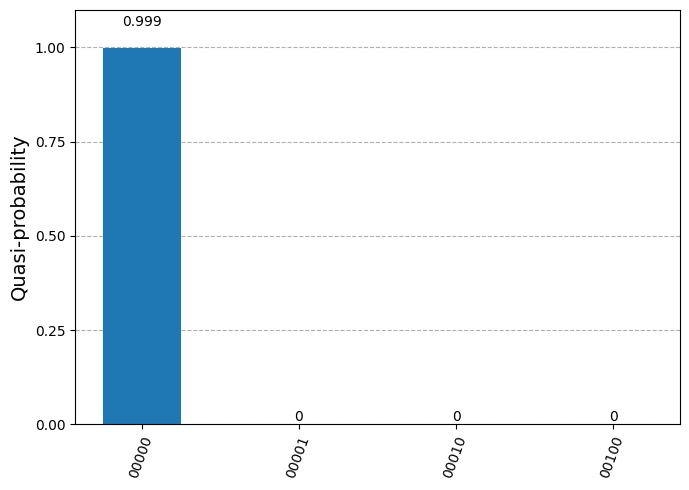

In [58]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)


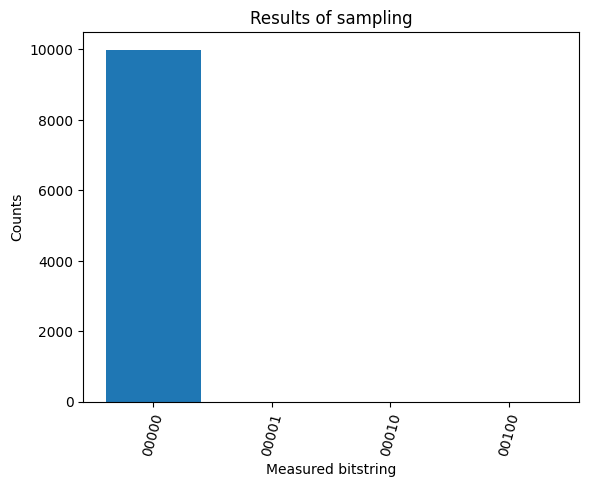

In [59]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()


visualize_counts(counts, overlap_circ.num_qubits)